In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


#### Loading dataset with confidence function (SR or MCD)

In [2]:
sgp_df_SR = pickle.load(open('sgp_set_cnn','rb')) 
print(sgp_df_SR.shape)
print('1s prop = ', sgp_df_SR.y_true.sum()/sgp_df_SR.shape[0])
sgp_df_SR.head() 

(6788, 3)
1s prop =  0.3320565704183854


,y_true,y_pred,kappa
0,0.0,0.0,0.985617
1,1.0,1.0,0.899486
2,1.0,1.0,0.952112
3,0.0,0.0,0.994921
4,0.0,0.0,0.978682


In [3]:
sgp_df_MCD = pickle.load(open('sgp_set_cnn_MCD','rb')) 
print(sgp_df_MCD.shape)
sgp_df_MCD.head() 

(6788, 3)


,y_true,y_pred,kappa
0,0.0,0.0,-0.000600
1,1.0,1.0,-0.003494
2,1.0,1.0,-0.001536
3,0.0,0.0,-0.000046
4,0.0,0.0,-0.001196


#### Random split into bounds-fitting and bounds-testing (with reproducible seed)

In [4]:
train_set_SR, test_set_SR = train_test_split(sgp_df_SR, seed=26) # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(sgp_df_MCD, seed=26) # same with MCD kappa confidence function

Setting experiments parameters

In [5]:
delta = 0.005

In [6]:
color_map = {'standard': "#d51414",
             'FP': "#a08611",
             'FN': "#1c9815",
             'FPR': "#403535",
             'FNR': "#1d3ae2",
             'SE': "#d51de2",
             'SP': "#118997",
             'PPV': "#676767"}

#### Joint evolution of metrics with respect to $\theta$ and coverage

standard  bounds


  0%|          | 0/50 [00:00<?, ?it/s]

 98%|█████████▊| 49/50 [00:02<00:00, 23.85it/s]


FP  bounds


 98%|█████████▊| 49/50 [00:01<00:00, 27.01it/s]


...

 98%|█████████▊| 49/50 [00:01<00:00, 26.45it/s]


SE  bounds


 88%|████████▊ | 44/50 [00:00<00:00, 139.65it/s]


SP  bounds


 98%|█████████▊| 49/50 [00:01<00:00, 26.79it/s]


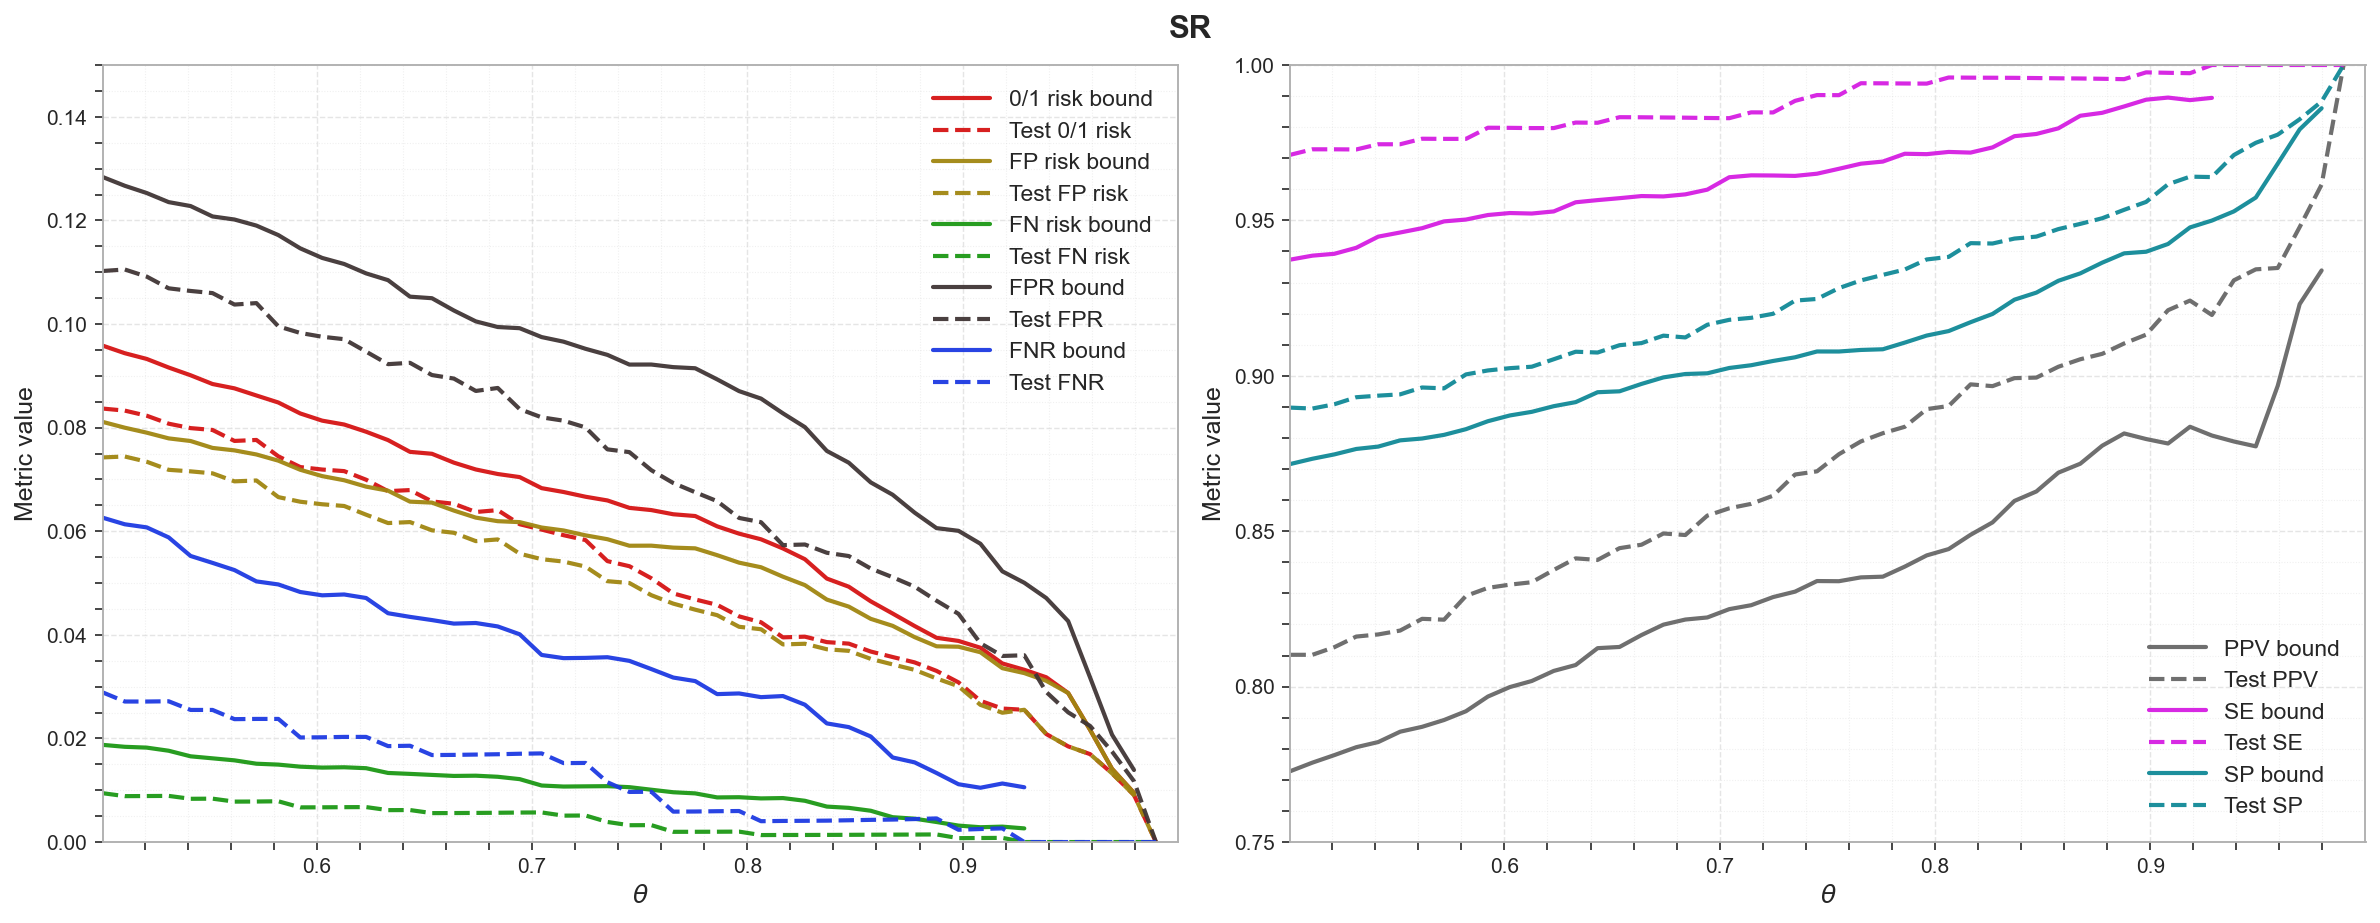

In [7]:
plot_all_metrics(train_set_SR, test_set_SR,
                 delta, color_map, title='SR',
                 xlim1=[0.5,1], xlim2=[0.5,1],
                 ylim1=[0,0.15], ylim2=[0.75,1])

standard  bounds


 98%|█████████▊| 49/50 [00:02<00:00, 23.75it/s]


FP  bounds


 98%|█████████▊| 49/50 [00:01<00:00, 26.51it/s]


FN  bounds


...

 98%|█████████▊| 49/50 [00:01<00:00, 26.61it/s]


SE  bounds


 88%|████████▊ | 44/50 [00:00<00:00, 140.65it/s]


SP  bounds


 98%|█████████▊| 49/50 [00:01<00:00, 26.11it/s]


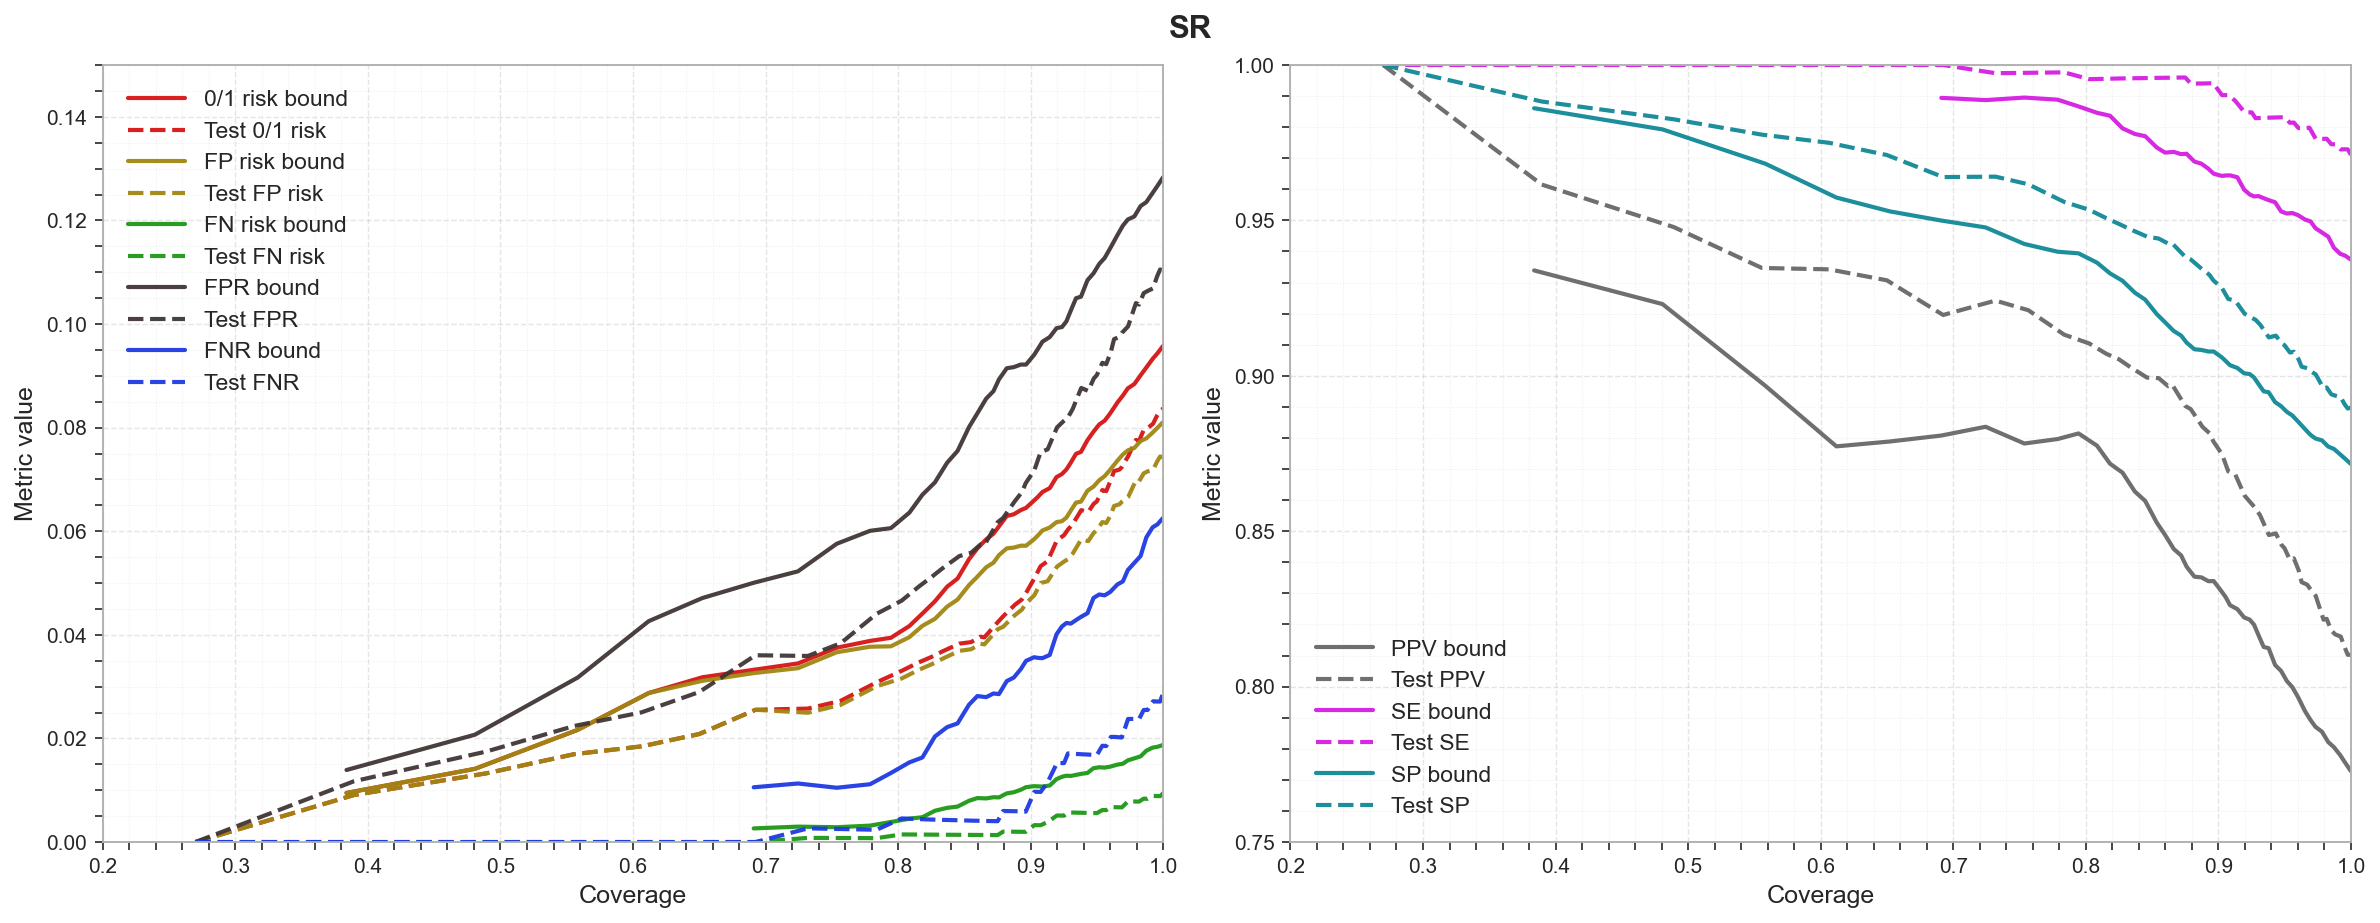

In [8]:
plot_all_metrics(train_set_SR, test_set_SR,
                 delta, color_map, title='SR',
                 xlim1=[0.2,1], xlim2=[0.2,1],
                 ylim1=[0,0.15], ylim2=[0.75,1],
                 by_coverage=True)

standard  bounds


 98%|█████████▊| 49/50 [00:03<00:00, 15.11it/s]


FP  bounds


 98%|█████████▊| 49/50 [00:02<00:00, 17.85it/s]


FN  bounds


...

 98%|█████████▊| 49/50 [00:02<00:00, 17.62it/s]


SE  bounds


 96%|█████████▌| 48/50 [00:00<00:00, 96.06it/s]


SP  bounds


 98%|█████████▊| 49/50 [00:02<00:00, 18.12it/s]


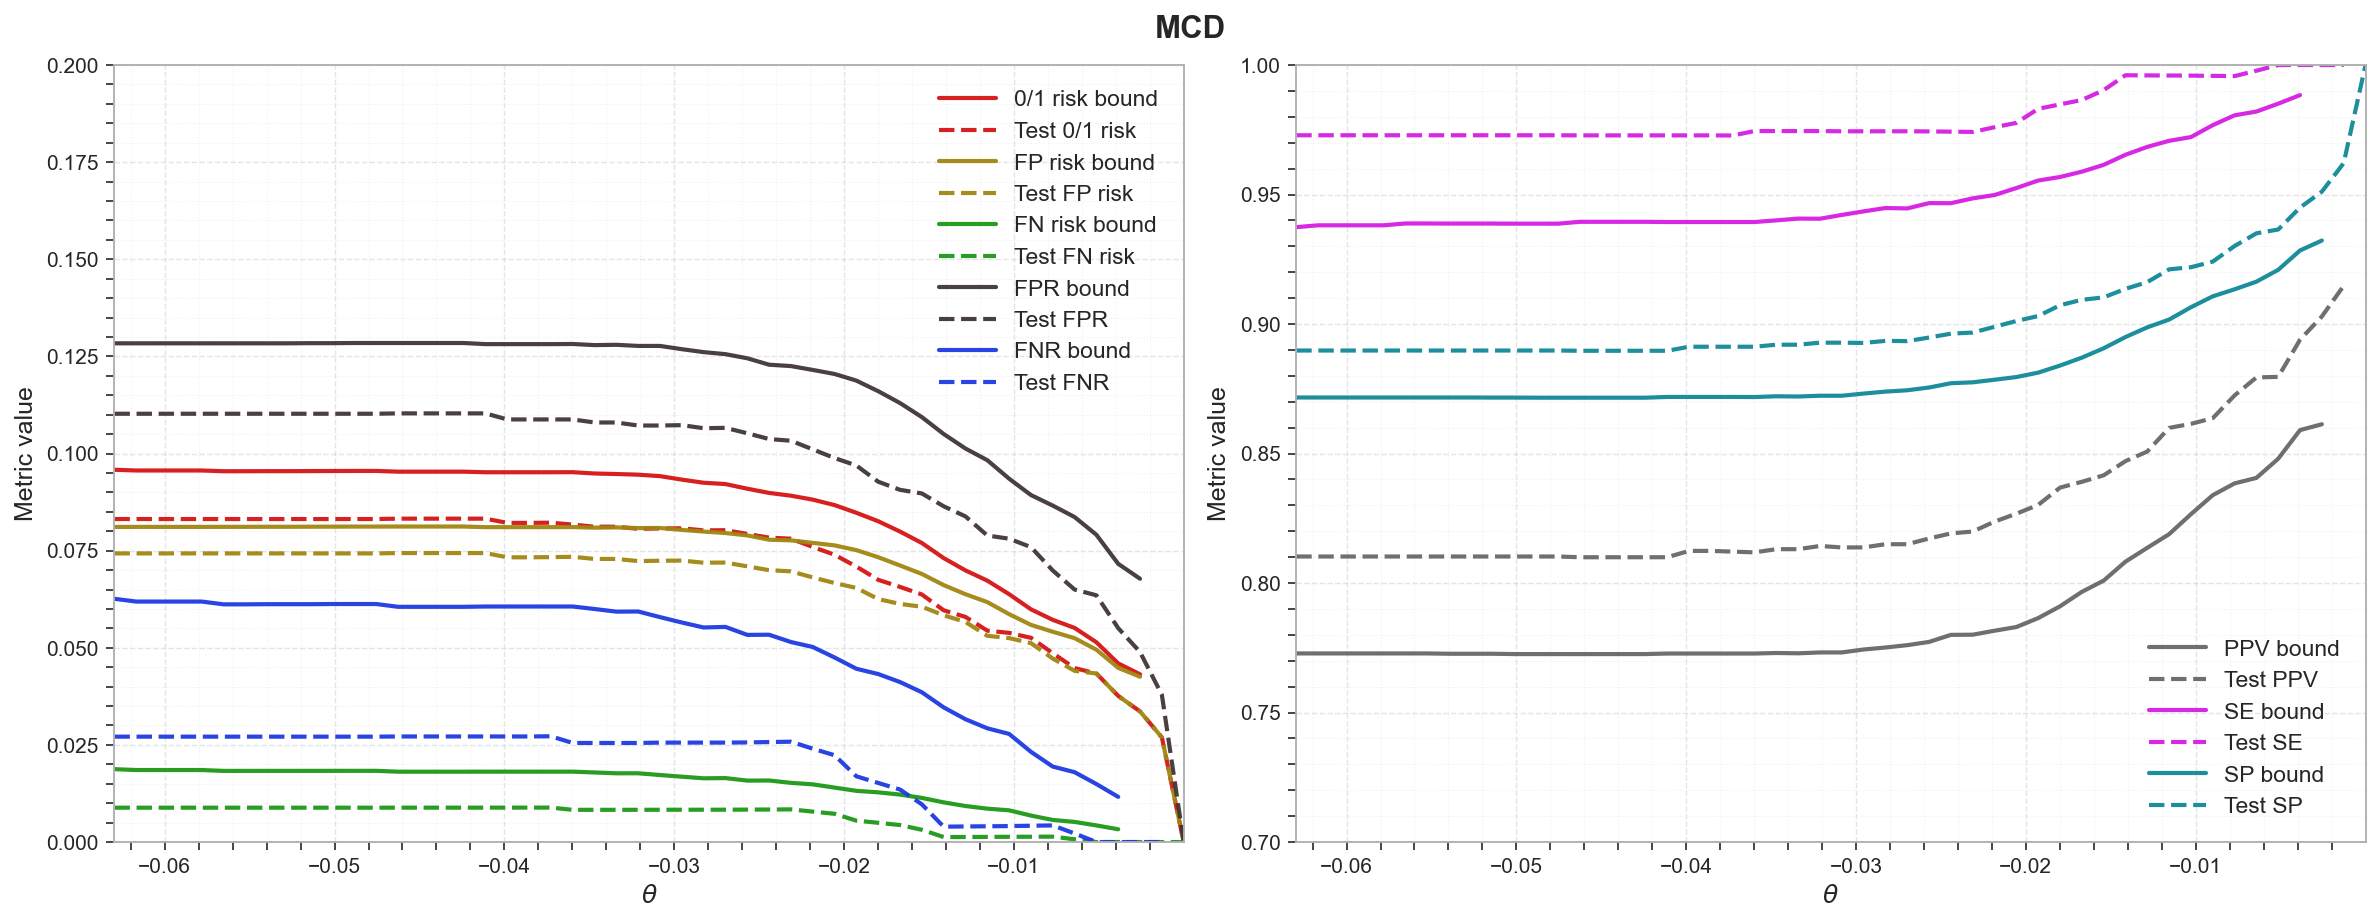

In [9]:
plot_all_metrics(train_set_MCD, test_set_MCD,
                 delta, color_map, title='MCD',
                 xlim1=[-0.07,0], xlim2=[-0.07,0],
                 ylim1=[0,0.2], ylim2=[0.7,1])

standard  bounds


 98%|█████████▊| 49/50 [00:03<00:00, 15.59it/s]


FP  bounds


 98%|█████████▊| 49/50 [00:02<00:00, 17.97it/s]


FN  bounds


...

 98%|█████████▊| 49/50 [00:02<00:00, 18.20it/s]


SE  bounds


 96%|█████████▌| 48/50 [00:00<00:00, 89.64it/s]


SP  bounds


 98%|█████████▊| 49/50 [00:02<00:00, 17.98it/s]


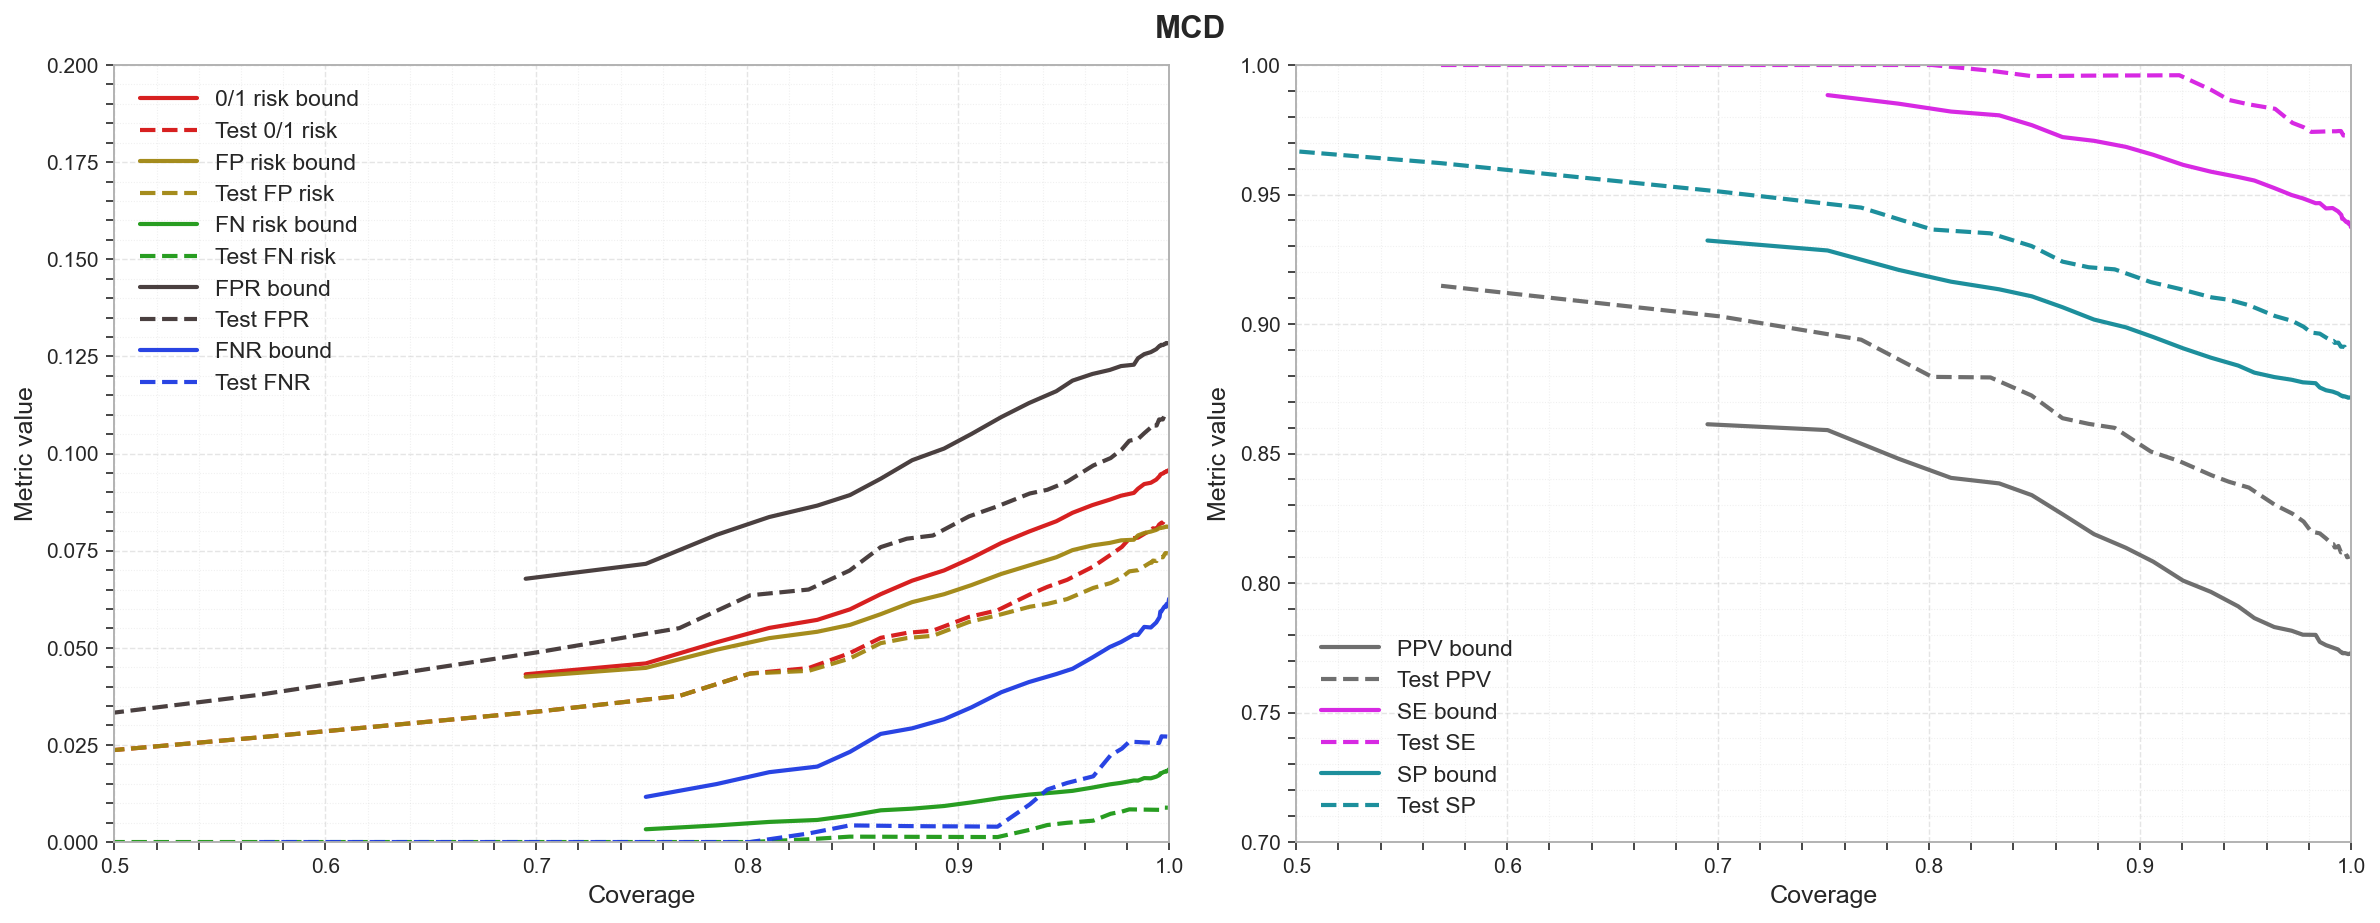

In [10]:
plot_all_metrics(train_set_MCD, test_set_MCD,
                 delta, color_map, title='MCD',
                 xlim1=[0.5,1], xlim2=[0.5,1],
                 ylim1=[0,0.2], ylim2=[0.7,1],
                 by_coverage=True)

#### Finding $\theta^*$ for joint control, if solutions set is non empty

In [11]:
metrics_and_targets = {'FNR' : 0.2,
                       'FPR' : 0.1}

In [12]:
joint_output = joint_control(metrics_and_targets, train_set_SR, delta, plot=False)
joint_output

FNR  bounds


 89%|████████▉ | 89/100 [00:00<00:00, 154.40it/s]


FPR  bounds


 98%|█████████▊| 98/100 [00:03<00:00, 25.73it/s]


{'theta_intervals': [(np.float64(0.6822143305431713),
   np.float64(0.939464088642236))],
 'best_theta': np.float64(0.6822143305431713)}

#### Displaying all bounds trade-offs for a couple of 2 metrics

In [13]:
metrics = ['standard', 'FP', 'FN', 'FPR',
           'FNR','PPV', 'SE','SP']

all_bounds_SR = reachable_bounds(metrics, train_set_SR, delta, steps=100)
all_bounds_MCD = reachable_bounds(metrics, train_set_MCD, delta, steps=100)

standard  bounds


 98%|█████████▊| 98/100 [00:04<00:00, 23.18it/s]


FP  bounds


 98%|█████████▊| 98/100 [00:03<00:00, 26.31it/s]


FN  bounds


...

 99%|█████████▉| 99/100 [00:05<00:00, 18.36it/s]


SE  bounds


 97%|█████████▋| 97/100 [00:01<00:00, 95.90it/s]


SP  bounds


 99%|█████████▉| 99/100 [00:05<00:00, 18.40it/s]


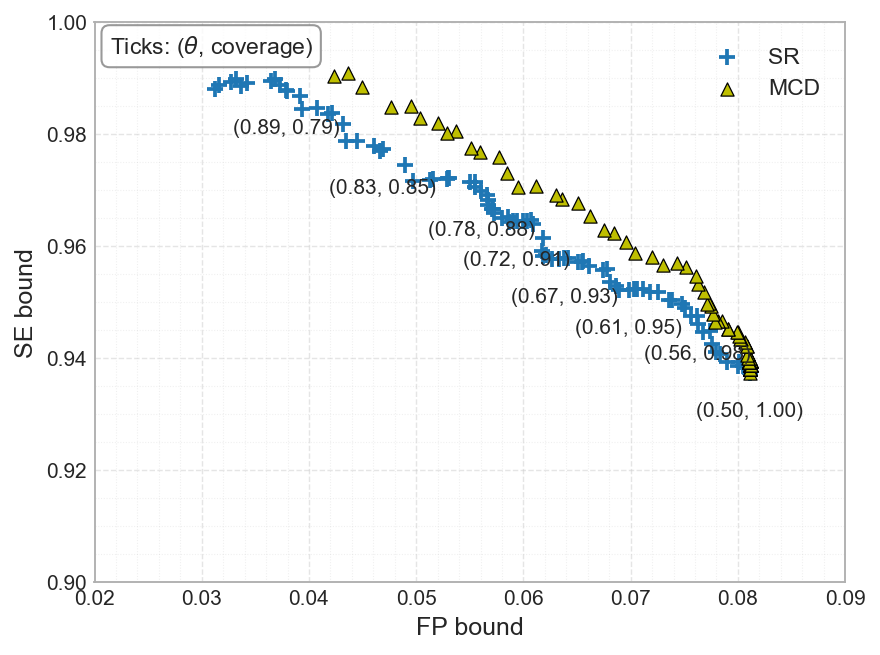

In [14]:
metric1 = 'FP'
metric2 = 'SE'

two_metrics_bounds(metric1, metric2, all_bounds_SR, all_bounds_MCD=all_bounds_MCD, num_labels=10,xlim=[0.02,0.09],ylim=[0.9,1])